# **模块**: 基于PCA的多元统计过程监控
## **课程**: PCA简介
### *主题*:  使用Sklearn在简单3D数据集上实现PCA

In [1]:
# 导入所需包
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
# 中文显示设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


from mpl_toolkits.mplot3d import Axes3D
np.set_printoptions(precision=3, suppress=True)


In [2]:
# ==================================================================================
#                        读取并探索数据集
# ==================================================================================

In [3]:
# 获取数据并探索
df = pd.read_csv('3D_numericalDataset.csv')

print("\n 前几行数据：")
print(df.head())

print("\n\n 基本统计量：")
print(df.describe())


 前几行数据：
         x         y          z
0  0.00000  1.331587  18.674287
1  0.10101  0.816289  18.987328
2  0.20202 -1.343380  21.095214
3  0.30303  0.294646  19.425811
4  0.40404  1.025376  18.563365


 基本统计量：
                x           y           z
count  100.000000  100.000000  100.000000
mean     5.000000    5.079417    9.924043
std      2.930454    3.014944    5.864905
min      0.000000   -1.343380   -0.566620
25%      2.500000    2.753592    5.294487
50%      5.000000    5.077250   10.026243
75%      7.500000    7.390400   14.347033
max     10.000000   10.725989   21.095214


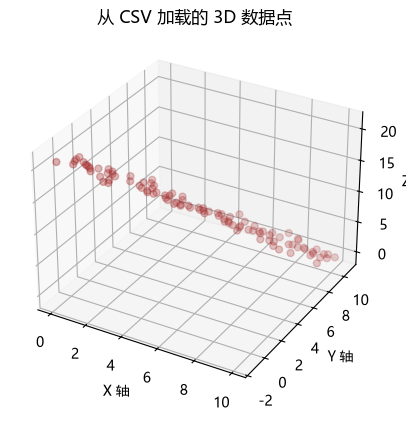

In [4]:
# 绘制数据
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(df['x'], df['y'], df['z'], c='brown', marker='o', alpha=0.6, s=25)

ax.set_xlabel('X 轴')
ax.set_ylabel('Y 轴')
ax.set_zlabel('Z 轴')
ax.set_title('从 CSV 加载的 3D 数据点')

plt.show()

In [5]:
# ==================================================================================
#                        拟合PCA模型 
# ==================================================================================

In [6]:
# 将Pandas数据框转换为Numpy数组
data = df.values # can continue working with dataframe as well
print('NumPy 数组：\n', data) 

NumPy 数组：
 [[ 0.     1.332 18.674]
 [ 0.101  0.816 18.987]
 [ 0.202 -1.343 21.095]
 [ 0.303  0.295 19.426]
 [ 0.404  1.025 18.563]
 [ 0.505 -0.215 19.69 ]
 [ 0.606  0.872 18.508]
 [ 0.707  0.816 18.52 ]
 [ 0.808  0.812 18.415]
 [ 0.909  0.734 18.317]
 [ 1.01   1.443 17.561]
 [ 1.111  2.314 16.551]
 [ 1.212  0.247 18.661]
 [ 1.313  2.341 16.308]
 [ 1.414  1.643 16.927]
 [ 1.515  1.96  16.507]
 [ 1.616  0.48  17.882]
 [ 1.717  1.852 16.438]
 [ 1.818  3.303 14.893]
 [ 1.919  0.839 17.16 ]
 [ 2.02   0.042 17.909]
 [ 2.121  0.378 17.435]
 [ 2.222  2.488 15.351]
 [ 2.323  4.708 13.092]
 [ 2.424  3.548 14.097]
 [ 2.525  4.198 13.294]
 [ 2.626  2.725 14.699]
 [ 2.727  4.125 13.156]
 [ 2.828  2.557 14.698]
 [ 2.929  3.542 13.562]
 [ 3.03   2.763 14.195]
 [ 3.131  2.582 14.23 ]
 [ 3.232  3.365 13.371]
 [ 3.333  2.857 13.825]
 [ 3.434  4.743 11.762]
 [ 3.535  3.73  12.723]
 [ 3.636  4.037 12.394]
 [ 3.737  3.4   12.864]
 [ 3.838  5.095 11.166]
 [ 3.939  3.207 12.926]
 [ 4.04   4.701 11.245]
 [ 4.

In [7]:
# 缩放数据
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
           
# 拟合仅含1个主成分的PCA
pca = PCA(n_components=1)
pca.fit(data_scaled)
score_1D = pca.transform(data_scaled) # could also do score_1D = pca.fit_transform(data_scaled)

print("一维空间中的变换数据：")
print(score_1D)


一维空间中的变换数据：
[[ 2.577]
 [ 2.687]
 [ 3.292]
 [ 2.791]
 [ 2.545]
 [ 2.875]
 [ 2.529]
 [ 2.521]
 [ 2.491]
 [ 2.477]
 [ 2.246]
 [ 1.958]
 [ 2.545]
 [ 1.889]
 [ 2.064]
 [ 1.942]
 [ 2.343]
 [ 1.916]
 [ 1.464]
 [ 2.142]
 [ 2.35 ]
 [ 2.218]
 [ 1.586]
 [ 0.915]
 [ 1.218]
 [ 0.993]
 [ 1.396]
 [ 0.953]
 [ 1.388]
 [ 1.066]
 [ 1.258]
 [ 1.277]
 [ 1.021]
 [ 1.144]
 [ 0.557]
 [ 0.827]
 [ 0.715]
 [ 0.864]
 [ 0.35 ]
 [ 0.867]
 [ 0.394]
 [ 0.623]
 [ 0.742]
 [ 0.549]
 [ 0.586]
 [ 0.36 ]
 [ 0.324]
 [ 0.078]
 [-0.051]
 [ 0.101]
 [ 0.003]
 [-0.149]
 [ 0.038]
 [-0.389]
 [-0.491]
 [-0.363]
 [-1.065]
 [-0.688]
 [-0.445]
 [-0.451]
 [-0.527]
 [-0.515]
 [-1.047]
 [-0.573]
 [-0.827]
 [-0.75 ]
 [-1.264]
 [-0.608]
 [-0.97 ]
 [-1.103]
 [-1.297]
 [-1.386]
 [-1.246]
 [-1.659]
 [-1.529]
 [-2.213]
 [-1.11 ]
 [-1.789]
 [-1.361]
 [-1.499]
 [-2.375]
 [-2.361]
 [-1.365]
 [-1.899]
 [-1.997]
 [-1.465]
 [-2.131]
 [-2.321]
 [-2.331]
 [-1.74 ]
 [-2.705]
 [-2.516]
 [-2.49 ]
 [-2.343]
 [-2.831]
 [-2.943]
 [-2.595]
 [-2.831]
 [-3.095

In [8]:
# ==================================================================================
#              由变换后的一维得分重构三维数据集
# ==================================================================================

In [9]:
# 由PCA重构
data_scaled_reconstructed = pca.inverse_transform(score_1D)
print('重构后的标准化 NumPy 数组：\n', data_scaled_reconstructed) 

重构后的标准化 NumPy 数组：
 [[-1.481 -1.481  1.501]
 [-1.544 -1.545  1.565]
 [-1.892 -1.892  1.917]
 [-1.604 -1.604  1.626]
 [-1.463 -1.463  1.483]
 [-1.652 -1.653  1.675]
 [-1.453 -1.454  1.473]
 [-1.449 -1.449  1.469]
 [-1.432 -1.432  1.451]
 [-1.423 -1.424  1.443]
 [-1.29  -1.291  1.308]
 [-1.125 -1.125  1.141]
 [-1.462 -1.463  1.482]
 [-1.085 -1.086  1.1  ]
 [-1.186 -1.187  1.203]
 [-1.116 -1.116  1.131]
 [-1.346 -1.347  1.365]
 [-1.101 -1.101  1.116]
 [-0.841 -0.841  0.853]
 [-1.231 -1.231  1.248]
 [-1.35  -1.351  1.369]
 [-1.275 -1.275  1.292]
 [-0.911 -0.912  0.924]
 [-0.526 -0.526  0.533]
 [-0.7   -0.7    0.709]
 [-0.571 -0.571  0.578]
 [-0.802 -0.802  0.813]
 [-0.548 -0.548  0.555]
 [-0.798 -0.798  0.808]
 [-0.612 -0.613  0.621]
 [-0.723 -0.723  0.733]
 [-0.734 -0.734  0.744]
 [-0.587 -0.587  0.595]
 [-0.657 -0.657  0.666]
 [-0.32  -0.32   0.324]
 [-0.475 -0.475  0.482]
 [-0.411 -0.411  0.417]
 [-0.497 -0.497  0.503]
 [-0.201 -0.201  0.204]
 [-0.498 -0.499  0.505]
 [-0.226 -0.226  0.22

In [10]:
# 缩放回原始尺度
data_reconstructed = scaler.inverse_transform(data_scaled_reconstructed)
print('重构后的 NumPy 数组：\n', data_reconstructed) 

重构后的 NumPy 数组：
 [[ 0.682  0.636 18.684]
 [ 0.497  0.446 19.059]
 [-0.515 -0.596 21.113]
 [ 0.323  0.267 19.412]
 [ 0.735  0.691 18.575]
 [ 0.182  0.121 19.698]
 [ 0.762  0.718 18.521]
 [ 0.775  0.732 18.494]
 [ 0.825  0.783 18.393]
 [ 0.85   0.809 18.343]
 [ 1.237  1.207 17.557]
 [ 1.719  1.703 16.58 ]
 [ 0.736  0.692 18.574]
 [ 1.835  1.823 16.344]
 [ 1.541  1.52  16.941]
 [ 1.746  1.731 16.524]
 [ 1.074  1.04  17.888]
 [ 1.79   1.776 16.436]
 [ 2.548  2.556 14.899]
 [ 1.411  1.386 17.205]
 [ 1.063  1.028 17.911]
 [ 1.283  1.255 17.464]
 [ 2.343  2.345 15.314]
 [ 3.467  3.502 13.034]
 [ 2.96   2.98  14.063]
 [ 3.336  3.367 13.3  ]
 [ 2.661  2.673 14.668]
 [ 3.402  3.435 13.165]
 [ 2.674  2.686 14.642]
 [ 3.214  3.242 13.547]
 [ 2.891  2.909 14.202]
 [ 2.861  2.878 14.264]
 [ 3.289  3.319 13.395]
 [ 3.084  3.107 13.812]
 [ 4.067  4.12  11.816]
 [ 3.615  3.654 12.734]
 [ 3.802  3.846 12.355]
 [ 3.552  3.589 12.862]
 [ 4.414  4.476 11.114]
 [ 3.547  3.584 12.872]
 [ 4.341  4.401 11.262]


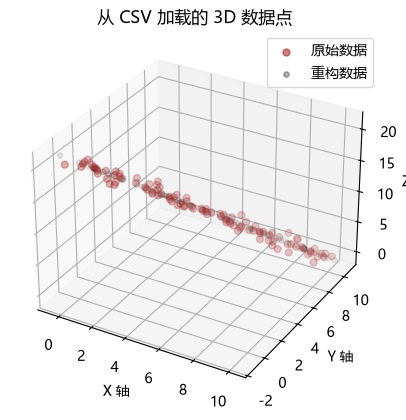

In [11]:
# 绘制原始与重构数据点
#%matplotlib qt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(data[:,0], data[:,1], data[:,2], c='brown', marker='o', alpha=0.6, s=25, label='原始数据')
ax.scatter(data_reconstructed[:,0], data_reconstructed[:,1], data_reconstructed[:,2], c='black', marker='o', alpha=0.3, s=15, label='重构数据')

ax.set_xlabel('X 轴')
ax.set_ylabel('Y 轴')
ax.set_zlabel('Z 轴')
ax.set_title('从 CSV 加载的 3D 数据点')

plt.legend()
plt.show()

>#### 借助PCA，我们可以从数据中去除噪声分量，并“提取”出观测样本所沿的一维直线！

In [12]:
# ==================================================================================
#              误差或残差矩阵
# ==================================================================================

In [13]:
errorMatrix = data - data_reconstructed
print('误差矩阵：\n', errorMatrix)

误差矩阵：
 [[-0.682  0.696 -0.01 ]
 [-0.396  0.37  -0.071]
 [ 0.717 -0.747 -0.018]
 [-0.02   0.028  0.014]
 [-0.331  0.334 -0.012]
 [ 0.323 -0.337 -0.008]
 [-0.156  0.153 -0.014]
 [-0.068  0.084  0.025]
 [-0.017  0.029  0.022]
 [ 0.059 -0.074 -0.026]
 [-0.227  0.236  0.004]
 [-0.608  0.611 -0.028]
 [ 0.476 -0.445  0.087]
 [-0.522  0.519 -0.036]
 [-0.127  0.123 -0.014]
 [-0.231  0.229 -0.017]
 [ 0.542 -0.56  -0.005]
 [-0.073  0.076  0.002]
 [-0.729  0.747 -0.006]
 [ 0.509 -0.546 -0.045]
 [ 0.957 -0.986 -0.002]
 [ 0.838 -0.877 -0.029]
 [-0.121  0.143  0.037]
 [-1.144  1.206  0.058]
 [-0.535  0.568  0.034]
 [-0.811  0.831 -0.006]
 [-0.035  0.052  0.031]
 [-0.675  0.69  -0.009]
 [ 0.154 -0.129  0.056]
 [-0.285  0.301  0.015]
 [ 0.139 -0.146 -0.007]
 [ 0.271 -0.296 -0.034]
 [-0.057  0.046 -0.024]
 [ 0.25  -0.25   0.013]
 [-0.633  0.623 -0.054]
 [-0.08   0.076 -0.011]
 [-0.165  0.19   0.039]
 [ 0.186 -0.189  0.003]
 [-0.575  0.619  0.052]
 [ 0.393 -0.376  0.053]
 [-0.3    0.3   -0.017]
 [ 0.186 

In [14]:
# ==================================================================================
#                   模型推断
# ==================================================================================

In [15]:
# 生成测试样本
x = 6
y = x + np.random.normal(0, 2*0.1)
z = 20 - x - y + 5

# 将坐标堆叠为单个数组
testSample = np.array((x,y,z))[None,:]
print(testSample)

[[ 6.     5.967 13.033]]


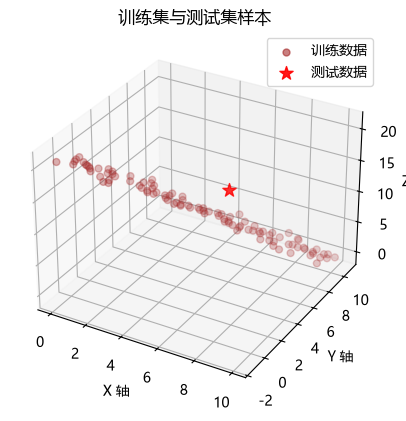

In [16]:
# 绘制训练与测试样本
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(data[:,0], data[:,1], data[:,2], c='brown', marker='o', alpha=0.6, s=25, label='训练数据')
ax.scatter(testSample[:,0], testSample[:,1], testSample[:,2], c='red', marker='*', alpha=0.9, s=100, label='测试数据')

ax.set_xlabel('X 轴')
ax.set_ylabel('Y 轴')
ax.set_zlabel('Z 轴')
ax.set_title('训练集与测试集样本')

plt.legend()
plt.show()

In [17]:
# 缩放测试样本
testSample_scaled = scaler.transform(testSample)
           
# 应用已拟合的PCA模型
testSample_score_1D = pca.transform(testSample_scaled)

# 重构 
testSample_scaled_reconstructed = pca.inverse_transform(testSample_score_1D)
testSample_reconstructed = scaler.inverse_transform(testSample_scaled_reconstructed)

print(testSample_reconstructed)

[[5.095 5.178 9.731]]


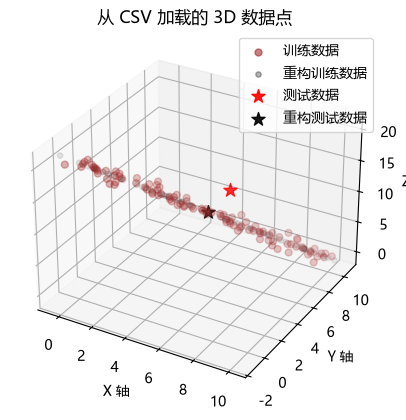

In [18]:
# 绘制原始与重构数据点
# %matplotlib qt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(data[:,0], data[:,1], data[:,2], c='brown', marker='o', alpha=0.6, s=25, label='训练数据')
ax.scatter(data_reconstructed[:,0], data_reconstructed[:,1], data_reconstructed[:,2], c='black', marker='o', alpha=0.3, s=15, label='重构训练数据')
ax.scatter(testSample[:,0], testSample[:,1], testSample[:,2], c='red', marker='*', alpha=0.9, s=100, label='测试数据')
ax.scatter(testSample_reconstructed[:,0], testSample_reconstructed[:,1], testSample_reconstructed[:,2], c='black', marker='*', alpha=0.9, s=100, label='重构测试数据')

ax.set_xlabel('X 轴')
ax.set_ylabel('Y 轴')
ax.set_zlabel('Z 轴')
ax.set_title('从 CSV 加载的 3D 数据点')

plt.legend()
plt.show()